# Single-molecule FRET from a database: the MMFDB burst workflow

This notebook runs a **complete single-molecule FRET analysis** on data stored
in **MMFDB**, the fluorescence database that ships with ChiSurf. You do **not**
need to be a programmer — each step is a single, plain-English line — but every
step also has knobs for when your experiment differs from the defaults.

The steps are:

1. **Connect** to a fluorescence database.
2. **Register** your measurements (upload once, get a handle back).
3. **Find bursts** — the individual molecules passing through the laser.
4. **Burst Variance Analysis (BVA)** — look for molecules that change shape.
5. **H2MM** — recover the FRET states photon-by-photon.

Everything is driven by one helper, `BurstWorkflow`, plus a `Setup` object that
names your detectors — for any number of dyes.

## 1. Connect to a database

`BurstWorkflow.demo()` starts a private, temporary database on your own
computer — perfect for learning, no setup needed. To use your lab's shared
MMFDB server instead, change just this one line:

```python
wf = BurstWorkflow.connect("http://mmfdb.mylab.org", user="you", password="…")
```

In [1]:
%matplotlib inline
import logging, warnings
for _noisy in ("numexpr", "mmfdb"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="nopython is set for njit")

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import chisurf
from chisurf.plugins.burst.burst_analysis.api import BurstWorkflow, Setup, Detector

wf = BurstWorkflow.demo()
print("Connected to a fluorescence database.")

Connected to a fluorescence database.


## 2. Register your measurements

Upload each raw file once; you get back a short **handle** that identifies the
dataset in the database from now on. `register_all` takes a whole list — here we
register three bundled Becker & Hickl single-molecule DNA measurements and
analyse them together. (`wf.register(one_file)` handles the single-file case.)

In [2]:
data_dir = (
    Path(chisurf.__file__).resolve().parent
    / "plugins/burst/burst_selection/tests/data/bh_spc132_sm_dna"
)
files = [data_dir / f"m00{i}.spc" for i in range(3)]

datasets = wf.register_all(files)
print("Registered", len(datasets), "datasets")
print("First handle:", datasets[0])

Registered 3 datasets
First handle: 19152d6d-ae9e-46b7-b4b2-04f1add5036a


## 3. Name your detectors, then find the bursts

A `Setup` gives a name to each detection channel — one entry per colour, for
**any number of dyes**. Names are just labels (no donor/acceptor is fixed here);
you choose which pair is the FRET pair later, at analysis time.

```python
setup = Setup.from_channels(green=(0, 8), red=(1, 9))                   # two colours
setup = Setup.from_channels(green=(0, 8), red=(1, 9), yellow=(2, 10))   # three colours
setup = Setup(detectors=[Detector('green', (0, 8), microtime_ranges=((0, 2048),)),
                         Detector('red',   (1, 9))])                    # PIE / ALEX gating
```

`select_bursts` fetches the datasets back by handle and detects bursts.
`min_photons` sets the smallest burst to keep; `method` chooses the search
algorithm (`"burst"`, `"count_rate"`, …).

In [3]:
setup = Setup.from_channels(green=(0, 8), red=(1, 9))

bursts = wf.select_bursts(datasets, setup=setup, min_photons=20, method="burst")
print(bursts)

<Bursts: 488 bursts from m000.spc, m001.spc, m002.spc>


## 4. Burst Variance Analysis (BVA)

BVA asks: *does a molecule's FRET change while we watch it?* Each burst is a
point; the red **shot-noise line** is what a rigid molecule would give. Points
**above** the line have internal dynamics. For more than two dyes, choose the
pair with `bursts.bva("green", "red")`.

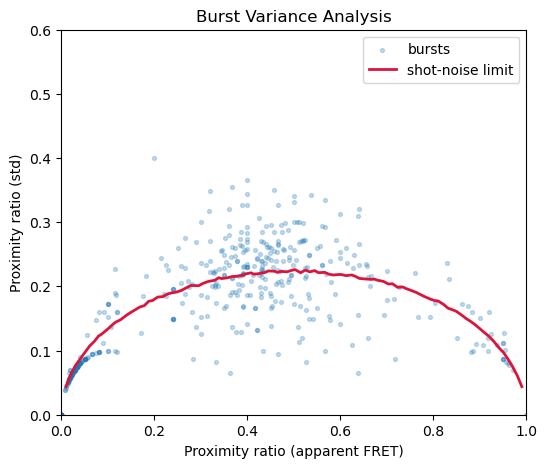

Average FRET (proximity ratio): 0.31
Bursts with dynamics (above the line): 41%


In [4]:
bva = bursts.bva()   # defaults to the first two detectors (green, red)
bva.plot()
plt.show()

print(f"Average FRET (proximity ratio): {bva.mean_proximity_ratio:.2f}")
print(f"Bursts with dynamics (above the line): {bva.dynamic_fraction:.0%}")

## 5. Photon-by-photon states with H2MM

> ⚠️ **Experimental.** ChiSurf's H2MM engine is validated against the reference
> implementation but is still being refined.

H2MM uses **every detector** in your setup (so three- or four-colour setups work
too) and works out how many distinct FRET **states** the molecules visit and how
populated each is. It picks the best number of states for you; the reported FRET
uses the first two detectors unless you pass `donor=`/`acceptor=`.

Best model: 3 state(s) (engine=em, criterion=bic)
  state 0: FRET E = 0.02, population = 36%
  state 1: FRET E = 0.43, population = 54%
  state 2: FRET E = 0.92, population = 10%


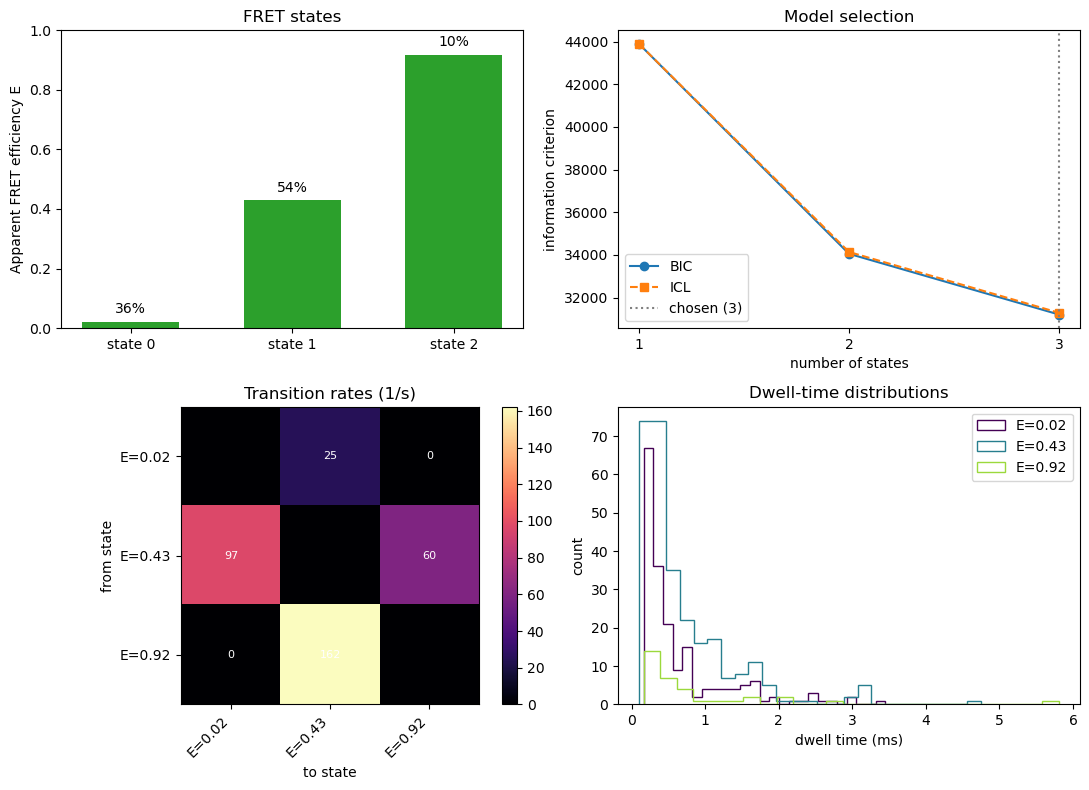

In [5]:
states = bursts.h2mm(states=(1, 2, 3))
print(states.summary())

states.plot()   # 2x2 dashboard: states, model selection, transitions, dwell times
plt.show()

## 6. No data yet? Simulate one with a known answer

The same database can hold **simulated** measurements. `wf.simulate` generates
photons with tttrlib for FRET states *you choose*, stores them in MMFDB, and
hands back the ground truth — so you can confirm the analysis recovers what you
put in before trusting it on real data. Everything downstream is identical.

Simulated FRET states: [0.2, 0.8] | MMFDB handle: 58026ba0


Best model: 2 state(s) (engine=em, criterion=bic)
  state 0: FRET E = 0.20, population = 49%
  state 1: FRET E = 0.80, population = 51%

Ground truth was: [0.2, 0.8]


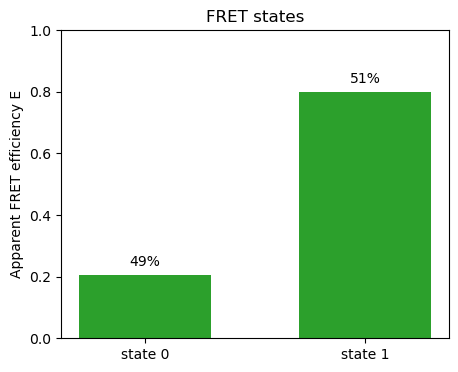

In [6]:
sim = wf.simulate(fret=(0.2, 0.8), exchange_rate=2.0)
print("Simulated FRET states:", sim.truth.fret.tolist(), "| MMFDB handle:", sim.handle[:8])

sim_bursts = wf.select_bursts(sim.handle, setup=sim.setup, min_photons=20)
recovered = sim_bursts.h2mm(states=(1, 2, 3))
print(recovered.summary())
print("\nGround truth was:", np.round(sim.truth.fret, 2).tolist())

recovered.plot_states()
plt.show()

The recovered efficiencies match the ones we asked for — the workflow is
trustworthy. See the H2MM-focused example for model-selection criteria, compute
engines, and static-vs-dynamic comparisons:
`chisurf/plugins/burst/burst_h2mm/examples/H2MM_02_MMFDB_GroundTruth.ipynb`.

## 7. Done

From registered measurements you found bursts, tested for dynamics with BVA, and
recovered the FRET states with H2MM — naming your detectors once and writing one
line per step. Add dyes to the `Setup`, choose a different FRET pair, or change
`method`, and the same five lines cover a different experiment. Close the demo
database when finished.

In [7]:
wf.close()
print("Finished.")

Finished.
